<a href="https://colab.research.google.com/github/ANU2478/AQI/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving cars.csv to cars.csv
{'cars.csv': b'brand,km_driven,fuel,owner,selling_price\nMaruti,145500,Diesel,First Owner,450000\nSkoda,120000,Diesel,Second Owner,370000\nHonda,140000,Petrol,Third Owner,158000\nHyundai,127000,Diesel,First Owner,225000\nMaruti,120000,Petrol,First Owner,130000\nHyundai,45000,Petrol,First Owner,440000\nMaruti,175000,LPG,First Owner,96000\nMaruti,5000,Petrol,Second Owner,45000\nToyota,90000,Diesel,First Owner,350000\nFord,169000,Diesel,First Owner,200000\nRenault,68000,Diesel,Second Owner,500000\nMaruti,100000,Petrol,Second Owner,92000\nMaruti,140000,Diesel,Second Owner,280000\nMaruti,80000,Petrol,Second Owner,200000\nMaruti,90000,Petrol,Second Owner,180000\nMahindra,40000,Petrol,First Owner,400000\nMaruti,70000,Diesel,Second Owner,778000\nHyundai,53000,Diesel,Second Owner,500000\nMaruti,80000,Petrol,Second Owner,150000\nHyundai,100000,Diesel,First Owner,680000\nMahindra,100000,Diesel,Second Owner,174000\nHonda,50000,Diesel,First Owner,950000\nMaruti,40000,Die

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
df = pd.read_csv('cars.csv')
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [ ]:
# check dataset
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   brand          8128 non-null   object
 1   km_driven      8128 non-null   int64 
 2   fuel           8128 non-null   object
 3   owner          8128 non-null   object
 4   selling_price  8128 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 317.6+ KB


,0
brand,0
km_driven,0
fuel,0
owner,0
selling_price,0


In [ ]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [ ]:
df.shape

(8128, 5)

In [ ]:


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Column Transformer

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         ['brand', 'fuel', 'owner'])
    ],
    remainder='passthrough'
)



In [ ]:
#Before training, check the unique values:
print(df['fuel'].unique())
print(df['owner'].unique())
print(df['brand'].unique())

['Diesel' 'Petrol' 'LPG' 'CNG']
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']
['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Fiat' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Audi' 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land' 'MG' 'Volvo'
 'Daewoo' 'Kia' 'Force' 'Ambassador' 'Ashok' 'Isuzu' 'Opel' 'Peugeot']


In [ ]:
#Random Forest Pipeline

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'fuel',
                                                   'owner'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [ ]:
#Check Accuracy

from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8232503012213058
MAE: 175700.40187018554


In [ ]:
#Save the Model

import joblib

joblib.dump(model, "car_price_model.pkl")

['car_price_model.pkl']

In [ ]:
from google.colab import files
files.download('car_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GRAPHS

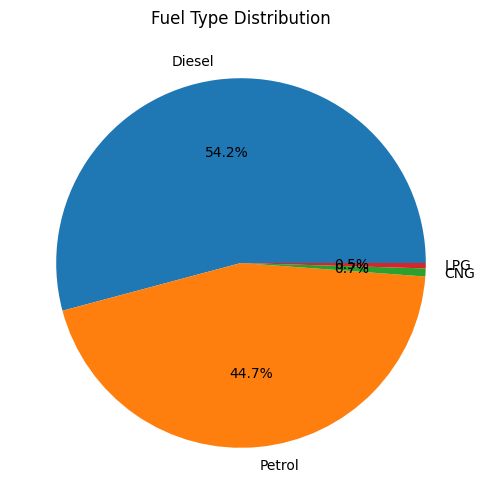

In [ ]:
import matplotlib.pyplot as plt

fuel_counts = df['fuel'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    fuel_counts,
    labels=fuel_counts.index,
    autopct='%1.1f%%'
)

plt.title('Fuel Type Distribution')
plt.show()

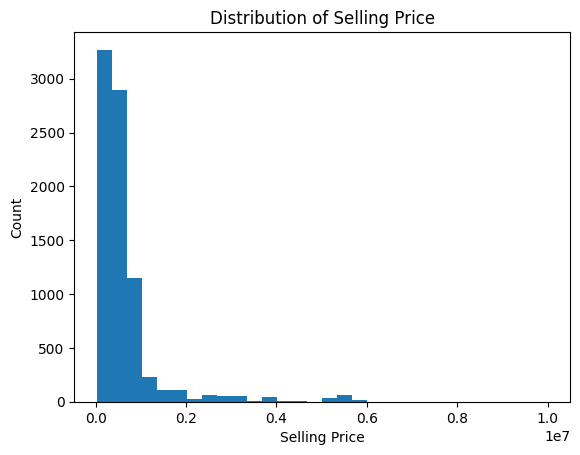

In [ ]:
# 1. Selling Price Distribution
plt.hist(df['selling_price'], bins=30)
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.title('Distribution of Selling Price')
plt.show()

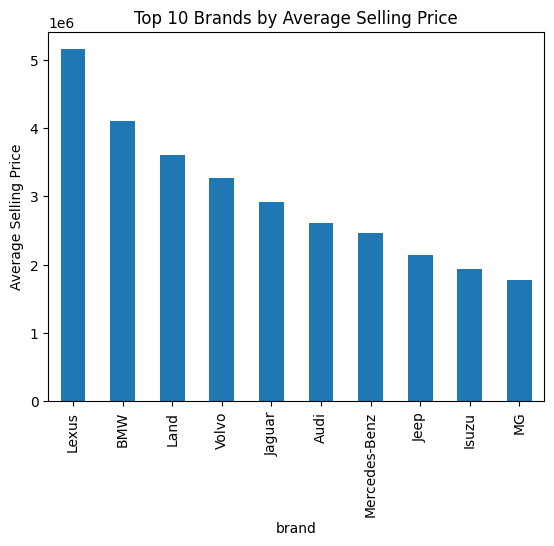

In [ ]:
# 2. Brand-wise Average Selling Price
brand_price = df.groupby('brand')['selling_price'].mean().sort_values(ascending=False)

brand_price.head(10).plot(kind='bar')
plt.title('Top 10 Brands by Average Selling Price')
plt.ylabel('Average Selling Price')
plt.show()

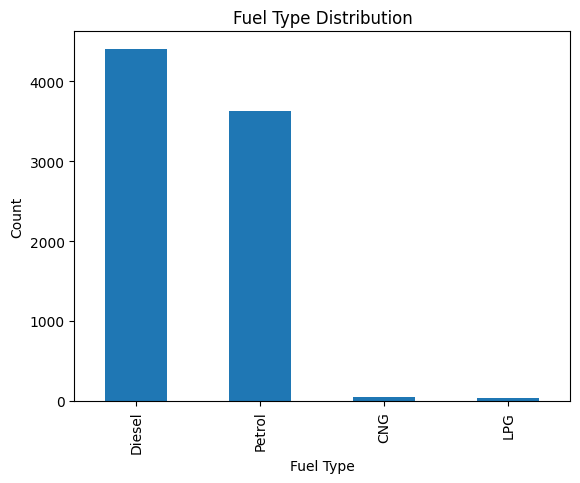

In [ ]:
# 3. Fuel Type Distribution
fuel_counts = df['fuel'].value_counts()

fuel_counts.plot(kind='bar')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.title('Fuel Type Distribution')
plt.show()

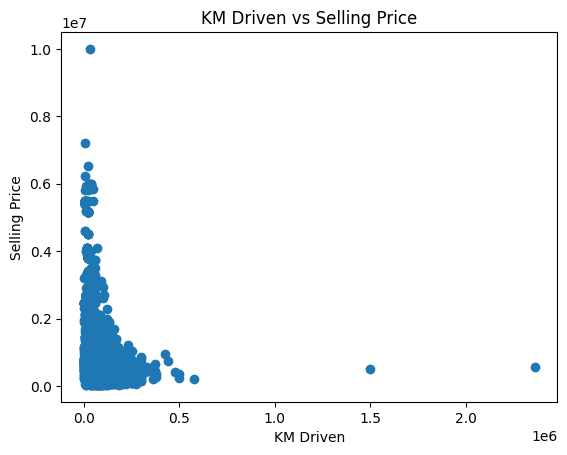

In [ ]:
# 4. KM Driven vs Selling Price
plt.scatter(df['km_driven'], df['selling_price'])
plt.xlabel('KM Driven')
plt.ylabel('Selling Price')
plt.title('KM Driven vs Selling Price')
plt.show()

In [ ]:
import sklearn
print(sklearn.__version__)


1.6.1


TypeError: 'tuple' object is not callable